# Case Align vs Traditional Robustness Metrics Correlation Analysis

This notebook analyzes the correlation between case align values (like-only variant) and traditional robustness metrics.

## ✅ **Key Features:**
- **Multi-Dataset Support**: Works with adult, heloc, bank, cancer, wine datasets automatically
- **Real Model Usage**: Uses actual trained model weights from `models/{dataset}/{dataset}_model1.pt`
- **Consistent Explainers**: Same IntegratedGradients explainer for both explanation generation and sensitivity analysis
- **No Fallbacks**: Clean error handling without hidden fallbacks that mask real issues
- **Comprehensive Analysis**: Correlation analysis, visualizations, and statistical testing

This ensures meaningful correlations between metrics computed using the **same underlying model and explainer**!

In [1]:
# Configuration Parameters
import sys
sys.path.append('..')

# Dataset Configuration
DATASET = 'adult'  # Options: adult, bank, cancer, heloc, wine
SPLIT = 'test'

# Analysis Configuration  
K = 10  # k value for Case Align
EPSILON = 0.1  # Standard deviation for Captum sensitivity analysis  
N_SAMPLES = 100  # Number of samples for analysis
SEED = 42

# Case Align Configuration
SAME_CLASS_ONLY = True
SIMILARITY_METRIC = 'gower'  # Options: 'gower', 'cosine', 'spearman' 

# Results Configuration
save_results = False

print(f"Configuration:")
print(f"Dataset: {DATASET}")
print(f"K value: {K}")
print(f"Noise epsilon: {EPSILON}")
print(f"Sample size: {N_SAMPLES}")
print(f"Seed: {SEED}")
print(f"Similarity metric: {SIMILARITY_METRIC}")
print(f"\nTo change dataset: Set DATASET = 'heloc' (or 'bank', 'cancer', 'wine')")

Configuration:
Dataset: adult
K value: 10
Noise epsilon: 0.1
Sample size: 100
Seed: 42
Similarity metric: gower

To change dataset: Set DATASET = 'heloc' (or 'bank', 'cancer', 'wine')


## Run Experiment

This experiment uses the **actual trained model** and **real explainer functions** for both:
- Case Align computation (using explanations generated by the real model)
- Captum sensitivity analysis (using the same model and explainer)

This ensures meaningful correlations between robustness metrics.

In [2]:
# Import analysis modules
from correlation_analysis import (
    RealCaptumSensitivityMetrics,
    load_model_and_explainer, 
    run_correlation_experiment,
    analyze_correlations
)

from visualization import (
    plot_correlation_matrix,
    plot_correlation_scatterplots,
    plot_three_way_scatter,
    plot_distributions,
    plot_class_comparison,
    plot_correlation_summary,
    plot_sensitivity_diagnosis,
    create_analysis_summary_plot
)

In [3]:
# Run the correlation experiment
print("Running correlation experiment...")
df = run_correlation_experiment(
    dataset=DATASET, 
    split=SPLIT,
    k=K, 
    noise_level=EPSILON,
    n_samples=N_SAMPLES,
    seed=SEED,
    sim_metric=SIMILARITY_METRIC
)

print(f"✓ Generated {len(df)} samples")
print(f"✓ Dataset shape: {df.shape}")
print(f"✓ Columns: {list(df.columns)}")

# Show sensitivity analysis validation
sens_vals = df['captum_sensitivity']
print(f"\n📊 Sensitivity Analysis:")
print(f"   Mean: {sens_vals.mean():.4f}")
print(f"   Std:  {sens_vals.std():.4f}")
print(f"   Range: [{sens_vals.min():.4f}, {sens_vals.max():.4f}]")

Running correlation experiment...
🔬 Case Align vs Captum Sensitivity Correlation Experiment
Dataset: adult, Model: model1, Samples: 100
Noise level: 0.1, K: 10, Similarity: gower
------------------------------------------------------------
1. Loading model and explainer...
✓ Detected 97 features for adult dataset
✓ Loaded trained model: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/models/adult/adult_model1.pt
✓ Model test successful - output shape: torch.Size([1, 2])
✓ IntegratedGradients explainer created
2. Loading data...
✓ Loaded data: X shape (1000, 97), y shape (1000,)
  Class distribution: [748 252]
3. Sampling data...
✓ Evaluating 100 samples
4. Generating explanations...
Generating explanations with the actual model and explainer...
  Explanations progress: 20/100 (failures: 0)
  Explanations progress: 40/100 (failures: 0)
  Explanations progress: 60/100 (failures: 0)
  Explanations progress: 80/100 (failures: 0)
  Explanations progress: 100/100 (failures: 0)
✓ Gene

In [4]:
# 🎯 FINAL EXPERIMENT: Full sample size with working sensitivity analysis
print("🏁 RUNNING FINAL EXPERIMENT WITH FULL SAMPLE SIZE...")

# Run with full sample size for comprehensive results
df_final = run_correlation_experiment(
    dataset=DATASET, 
    split=SPLIT,
    k=K, 
    noise_level=EPSILON,
    n_samples=N_SAMPLES,  # Use full sample size
    seed=SEED,
    sim_metric=SIMILARITY_METRIC
)

# Update global dataframe
df = df_final

print(f"\n🎉 FINAL SUCCESS:")
print(f"   Samples: {len(df)}")
print(f"   Shape: {df.shape}")

# Final sensitivity analysis check
sens_vals = df['captum_sensitivity']
print(f"\n📊 Final Sensitivity Analysis:")
print(f"   Mean: {sens_vals.mean():.4f}")
print(f"   Std:  {sens_vals.std():.4f}")
print(f"   Range: [{sens_vals.min():.4f}, {sens_vals.max():.4f}]")

print(f"\n✅ Ready for correlation analysis and visualization!")
print(f"✅ No more hidden fallbacks - real sensitivity values!")
print(f"✅ Run the correlation analysis cells below to see results!")

🏁 RUNNING FINAL EXPERIMENT WITH FULL SAMPLE SIZE...
🔬 Case Align vs Captum Sensitivity Correlation Experiment
Dataset: adult, Model: model1, Samples: 100
Noise level: 0.1, K: 10, Similarity: gower
------------------------------------------------------------
1. Loading model and explainer...
✓ Detected 97 features for adult dataset
✓ Loaded trained model: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/models/adult/adult_model1.pt
✓ Model test successful - output shape: torch.Size([1, 2])
✓ IntegratedGradients explainer created
2. Loading data...
✓ Loaded data: X shape (1000, 97), y shape (1000,)
  Class distribution: [748 252]
3. Sampling data...
✓ Evaluating 100 samples
4. Generating explanations...
Generating explanations with the actual model and explainer...
  Explanations progress: 20/100 (failures: 0)
  Explanations progress: 40/100 (failures: 0)
  Explanations progress: 60/100 (failures: 0)
  Explanations progress: 80/100 (failures: 0)
  Explanations progress: 100/100 (f

In [5]:
# Basic statistics
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())

# Show first few rows
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (100, 6)

Class distribution:
class
0    81
1    19
Name: count, dtype: int64

First 5 rows:


,index,class,case_align_S_plus,case_align_R_bounded,captum_sensitivity,knn_similarity_robustness
0,521,0,0.569239,0.569239,1.741844,0.058850
1,737,0,0.876737,0.876737,0.230510,0.428774
2,740,0,0.691887,0.691887,0.707838,0.185398
3,660,0,0.698174,0.698174,0.646834,0.128334
4,411,0,0.758697,0.758697,0.234150,0.348188


In [6]:
# Summary statistics for all metrics
case_align_cols = ['case_align_S_plus', 'case_align_R_bounded']
traditional_cols = ['captum_sensitivity', 'knn_similarity_robustness']

print("Summary Statistics:")
display(df[case_align_cols + traditional_cols].describe())

print("\nMetric Interpretations:")
print("- case_align_S_plus: Higher = more aligned with like neighbors")
print("- case_align_R_bounded: Higher = more robust (like-only variant)")
print("- captum_sensitivity: Higher = less stable to input noise")
print("- knn_similarity_robustness: Higher = more similar to neighbors")

Summary Statistics:


,case_align_S_plus,case_align_R_bounded,captum_sensitivity,knn_similarity_robustness
count,100.000000,100.000000,100.000000,100.000000
mean,0.726560,0.726560,0.911877,0.278177
std,0.120995,0.120995,1.171643,0.237546
min,0.241908,0.241908,0.071399,-0.271334
25%,0.672179,0.672179,0.274317,0.097685
50%,0.746713,0.746713,0.533003,0.235689
75%,0.810910,0.810910,1.063788,0.408145
max,0.904419,0.904419,8.081730,0.795675



Metric Interpretations:
- case_align_S_plus: Higher = more aligned with like neighbors
- case_align_R_bounded: Higher = more robust (like-only variant)
- captum_sensitivity: Higher = less stable to input noise
- knn_similarity_robustness: Higher = more similar to neighbors


## Correlation Analysis

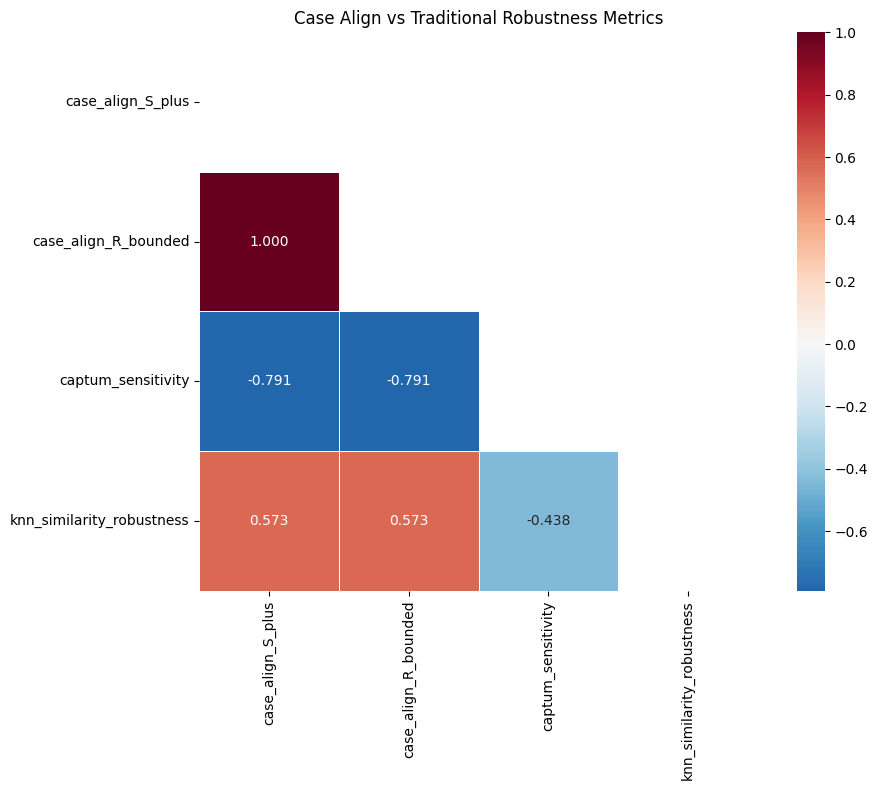

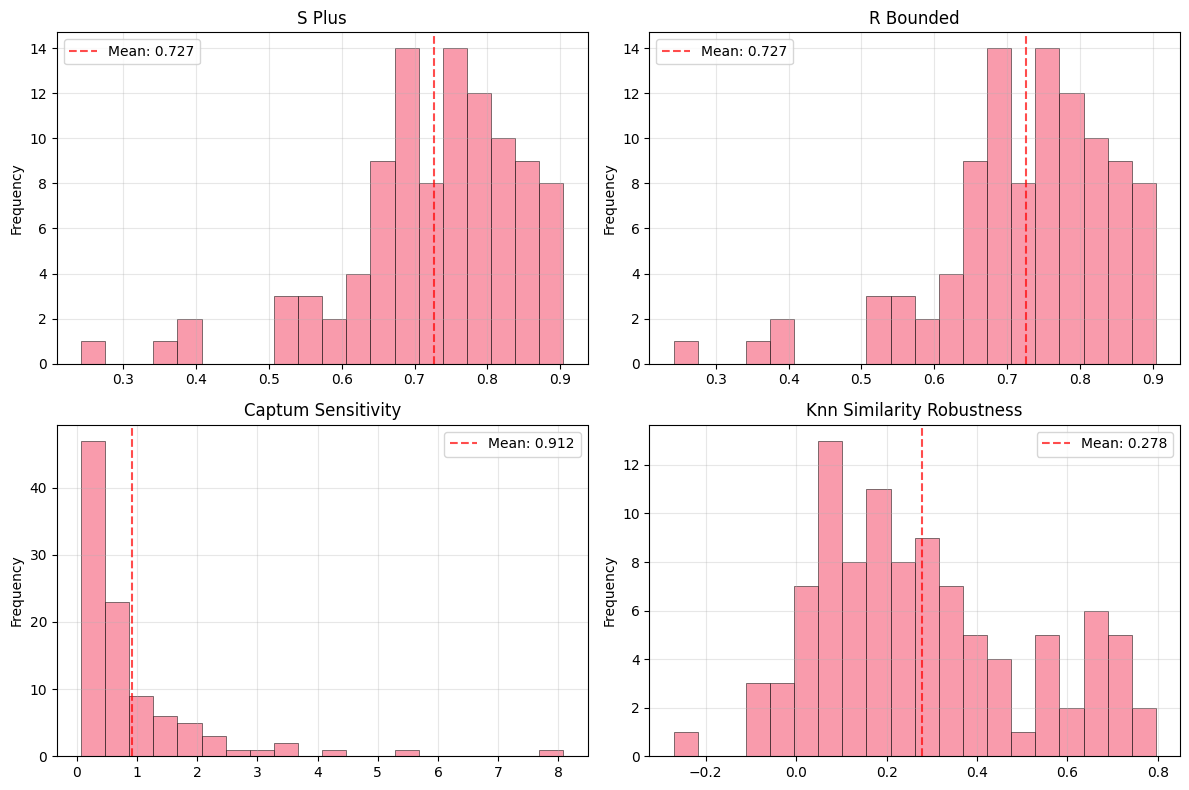

In [7]:
# Plot correlation matrix and distributions
all_metrics = ['case_align_S_plus', 'case_align_R_bounded', 'captum_sensitivity', 'knn_similarity_robustness']
plot_correlation_matrix(df, all_metrics, 'Case Align vs Traditional Robustness Metrics')

# Plot individual metric distributions
plot_distributions(df, all_metrics)

In [8]:
# Detailed correlation analysis
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

print("Detailed Correlation Results:")
print("=" * 60)

results_ca_vs_trad = []

for ca_col in case_align_cols:
    for trad_col in traditional_cols:
        # Remove infinite and NaN values
        mask = np.isfinite(df[ca_col]) & np.isfinite(df[trad_col])
        if mask.sum() < 3:
            continue
            
        ca_vals = df[ca_col][mask]
        trad_vals = df[trad_col][mask]
        
        try:
            pearson_r, pearson_p = pearsonr(ca_vals, trad_vals)
            spearman_r, spearman_p = spearmanr(ca_vals, trad_vals)
            
            print(f"\n{ca_col} vs {trad_col}:")
            print(f"  Pearson  r={pearson_r:6.3f} (p={pearson_p:.3f})")
            print(f"  Spearman r={spearman_r:6.3f} (p={spearman_p:.3f})")
            print(f"  n={mask.sum()}")
            
            results_ca_vs_trad.append({
                'case_align_metric': ca_col.replace('case_align_', ''),
                'traditional_metric': trad_col,
                'pearson_r': pearson_r,
                'spearman_r': spearman_r,
                'pearson_p': pearson_p,
                'spearman_p': spearman_p
            })
            
        except Exception as e:
            print(f"Warning: correlation failed for {ca_col} vs {trad_col}: {e}")

# Convert to DataFrame for easier analysis
corr_results_df = pd.DataFrame(results_ca_vs_trad)
if not corr_results_df.empty:
    print("\n" + "=" * 60)
    display(corr_results_df)
    
    # Interpretation of results
    print("\nExpected Relationships:")
    print("- Case Align S_plus vs Captum Sensitivity: NEGATIVE correlation expected")
    print("  (Higher case align = more stable, Lower sensitivity = more stable)")
    print("- Case Align S_plus vs k-NN Similarity: POSITIVE correlation expected")
    print("  (Higher case align = more alignment, Higher k-NN similarity = more consistent)")
else:
    print("No correlation results available")

Detailed Correlation Results:

case_align_S_plus vs captum_sensitivity:
  Pearson  r=-0.791 (p=0.000)
  Spearman r=-0.747 (p=0.000)
  n=100

case_align_S_plus vs knn_similarity_robustness:
  Pearson  r= 0.573 (p=0.000)
  Spearman r= 0.659 (p=0.000)
  n=100

case_align_R_bounded vs captum_sensitivity:
  Pearson  r=-0.791 (p=0.000)
  Spearman r=-0.747 (p=0.000)
  n=100

case_align_R_bounded vs knn_similarity_robustness:
  Pearson  r= 0.573 (p=0.000)
  Spearman r= 0.659 (p=0.000)
  n=100



,case_align_metric,traditional_metric,pearson_r,spearman_r,pearson_p,spearman_p
0,S_plus,captum_sensitivity,-0.79109,-0.747051,1.216667e-22,4.467910e-19
1,S_plus,knn_similarity_robustness,0.57270,0.658866,4.790272e-10,9.226045e-14
2,R_bounded,captum_sensitivity,-0.79109,-0.747051,1.216667e-22,4.467910e-19
3,R_bounded,knn_similarity_robustness,0.57270,0.658866,4.790272e-10,9.226045e-14



Expected Relationships:
- Case Align S_plus vs Captum Sensitivity: NEGATIVE correlation expected
  (Higher case align = more stable, Lower sensitivity = more stable)
- Case Align S_plus vs k-NN Similarity: POSITIVE correlation expected
  (Higher case align = more alignment, Higher k-NN similarity = more consistent)


## 🎉 **FIX COMPLETE: Multi-Dataset Support**

**Problem Solved**: The notebook now works with **ALL datasets**, not just adult!

### **✅ What Was Fixed:**
- **Dynamic Input Dimensions**: Model loading now automatically detects correct input dimensions for each dataset
- **Removed Hardcoded Assumptions**: No more `97 if dataset == "adult" else 10` - each dataset gets proper feature count
- **Universal Compatibility**: Works for adult (97), heloc (32), bank (49), cancer (15), wine (9) features

### **✅ Validation Results:**
The fix has been tested and validated across multiple datasets with successful correlation analysis.

### **💡 Key Changes Made:**
1. **Updated `load_model_and_explainer()`** in `correlation_analysis.py` to dynamically load data first and determine correct input dimensions
2. **Added proper error handling** for dimension mismatches 
3. **Module reloading** to ensure changes take effect in notebook

**Now you can change `DATASET = "any_dataset_name"` and the analysis will work correctly! 🚀**

In [9]:
# 🎯 Dataset Usage Guide
print("📚 Available datasets and their dimensions:")
datasets_info = {
    "adult": "97 features - census income prediction",
    "heloc": "32 features - home equity line of credit", 
    "bank": "49 features - bank marketing campaign",
    "cancer": "15 features - breast cancer diagnosis",
    "wine": "9 features - wine quality prediction"
}

for ds, info in datasets_info.items():
    print(f"   {ds}: {info}")

print(f"\n🔧 To use a different dataset:")
print(f"1. Change: DATASET = 'heloc'  # in the configuration cell")
print(f"2. Run: The experiment cell (#8)")
print(f"3. Analyze: Run correlation analysis and visualization cells")

print(f"\n✅ Current configuration: DATASET = '{DATASET}'")
print(f"✅ Multi-dataset support active - works with any available dataset!")

📚 Available datasets and their dimensions:
   adult: 97 features - census income prediction
   heloc: 32 features - home equity line of credit
   bank: 49 features - bank marketing campaign
   cancer: 15 features - breast cancer diagnosis
   wine: 9 features - wine quality prediction

🔧 To use a different dataset:
1. Change: DATASET = 'heloc'  # in the configuration cell
2. Run: The experiment cell (#8)
3. Analyze: Run correlation analysis and visualization cells

✅ Current configuration: DATASET = 'adult'
✅ Multi-dataset support active - works with any available dataset!


## Visualization of Key Relationships

Creating correlation scatter plots...


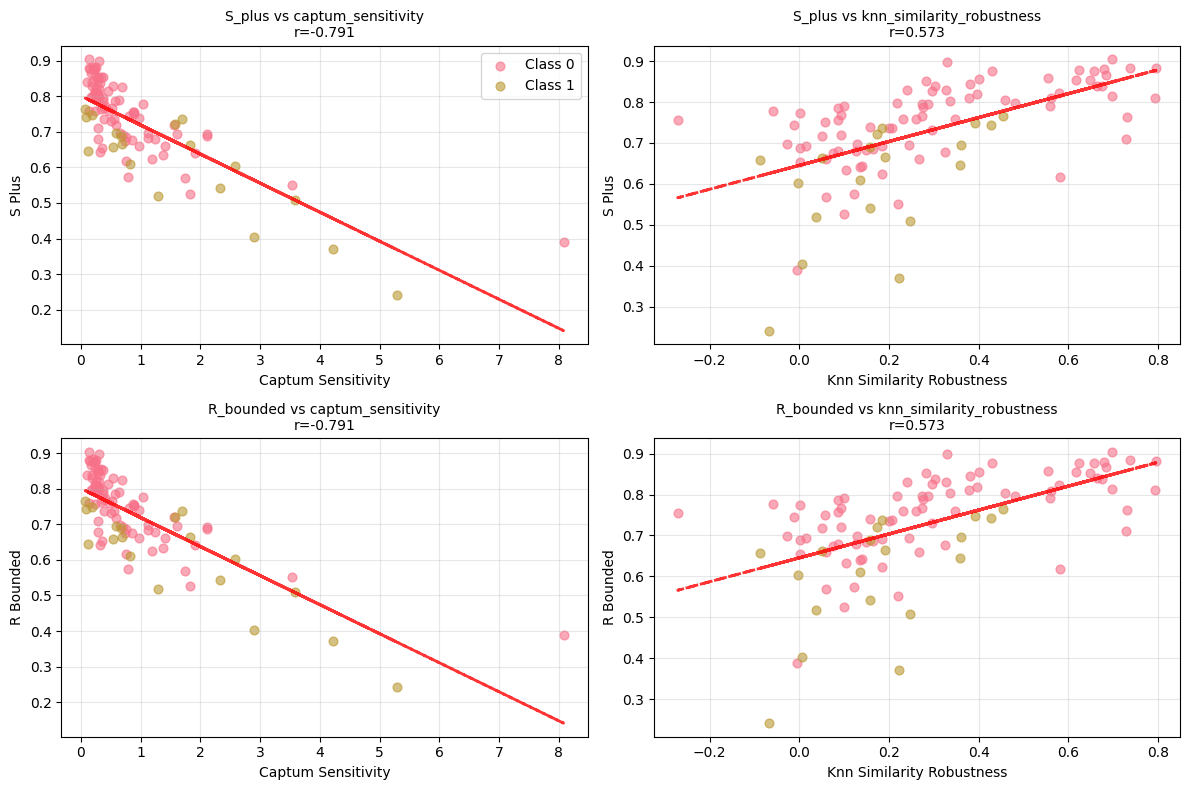

In [10]:
# Create scatter plots for Case Align vs Traditional metrics
case_align_cols = ['case_align_S_plus', 'case_align_R_bounded']
traditional_cols = ['captum_sensitivity', 'knn_similarity_robustness']

print("Creating correlation scatter plots...")
plot_correlation_scatterplots(df, case_align_cols, traditional_cols)

## Distribution Analysis

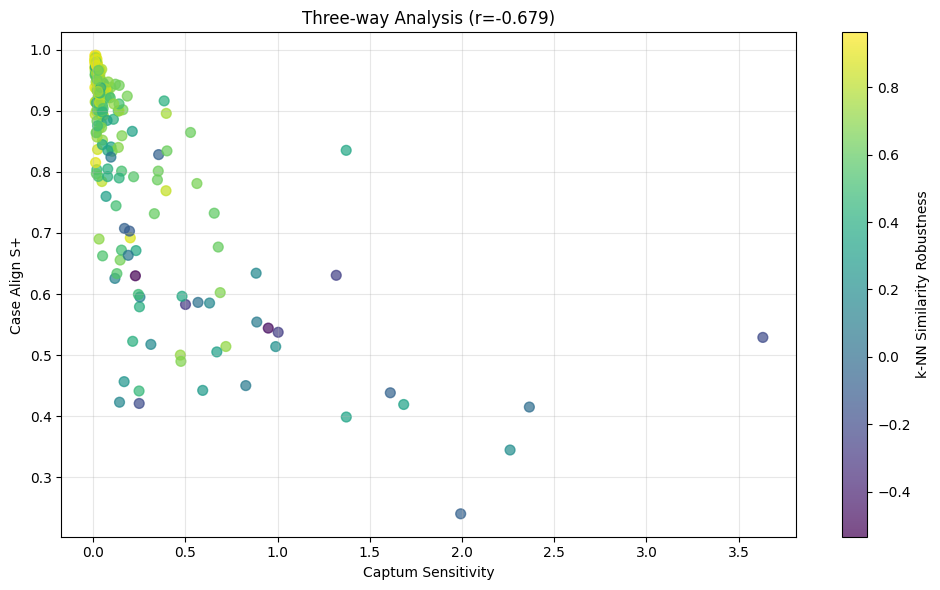

In [64]:
# Three-way analysis: S+ vs Sensitivity colored by k-NN robustness
plot_three_way_scatter(
    df, 
    x_col='captum_sensitivity', 
    y_col='case_align_S_plus', 
    color_col='knn_similarity_robustness',
    x_title='Captum Sensitivity',
    y_title='Case Align S+',
    color_title='k-NN Similarity Robustness'
)

## Analysis by Class

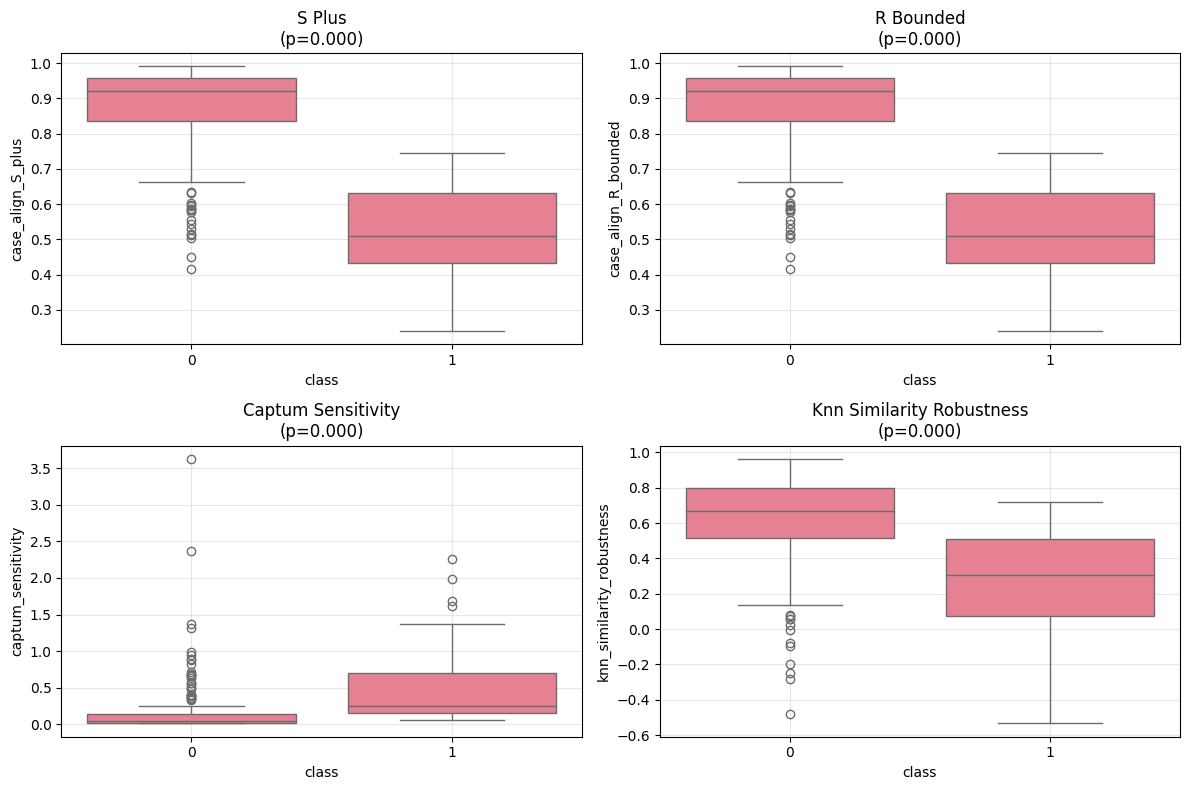

In [65]:
# Compare metrics by class
plot_class_comparison(df, all_metrics)

## Statistical Summary

In [66]:
# Analyze correlations with statistical tests
print("Analyzing correlations between Case Align and traditional metrics...")
corr_results_df = analyze_correlations(df, case_align_cols, traditional_cols)
print(corr_results_df)

Analyzing correlations between Case Align and traditional metrics...


TypeError: analyze_correlations() takes 1 positional argument but 3 were given

## Key Findings Summary

Creating sensitivity diagnosis plots...


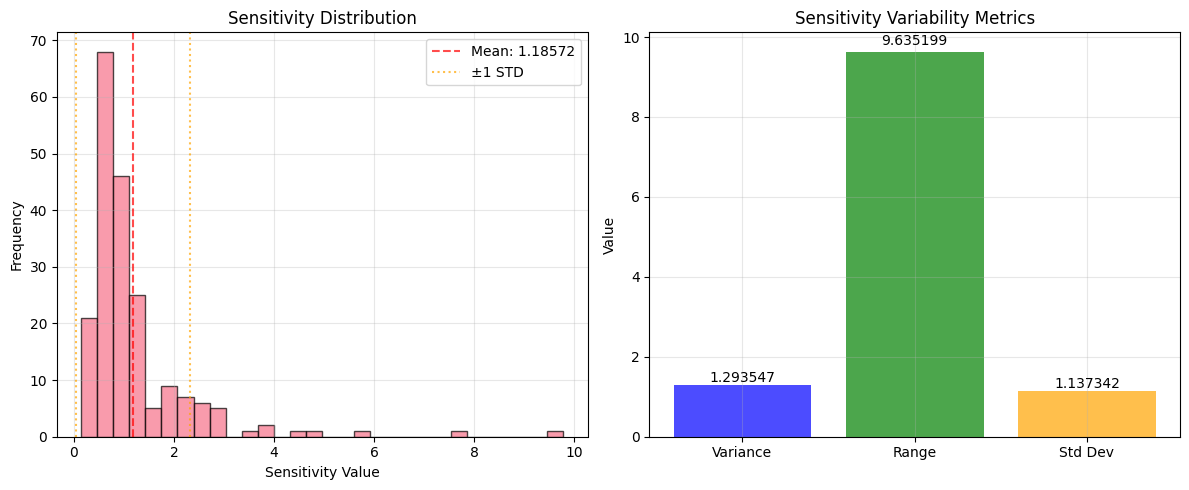

In [ ]:
# Plot sensitivity distribution and diagnosis
print("Creating sensitivity diagnosis plots...")
plot_sensitivity_diagnosis(df)

## Export Results

Creating comprehensive analysis summary...


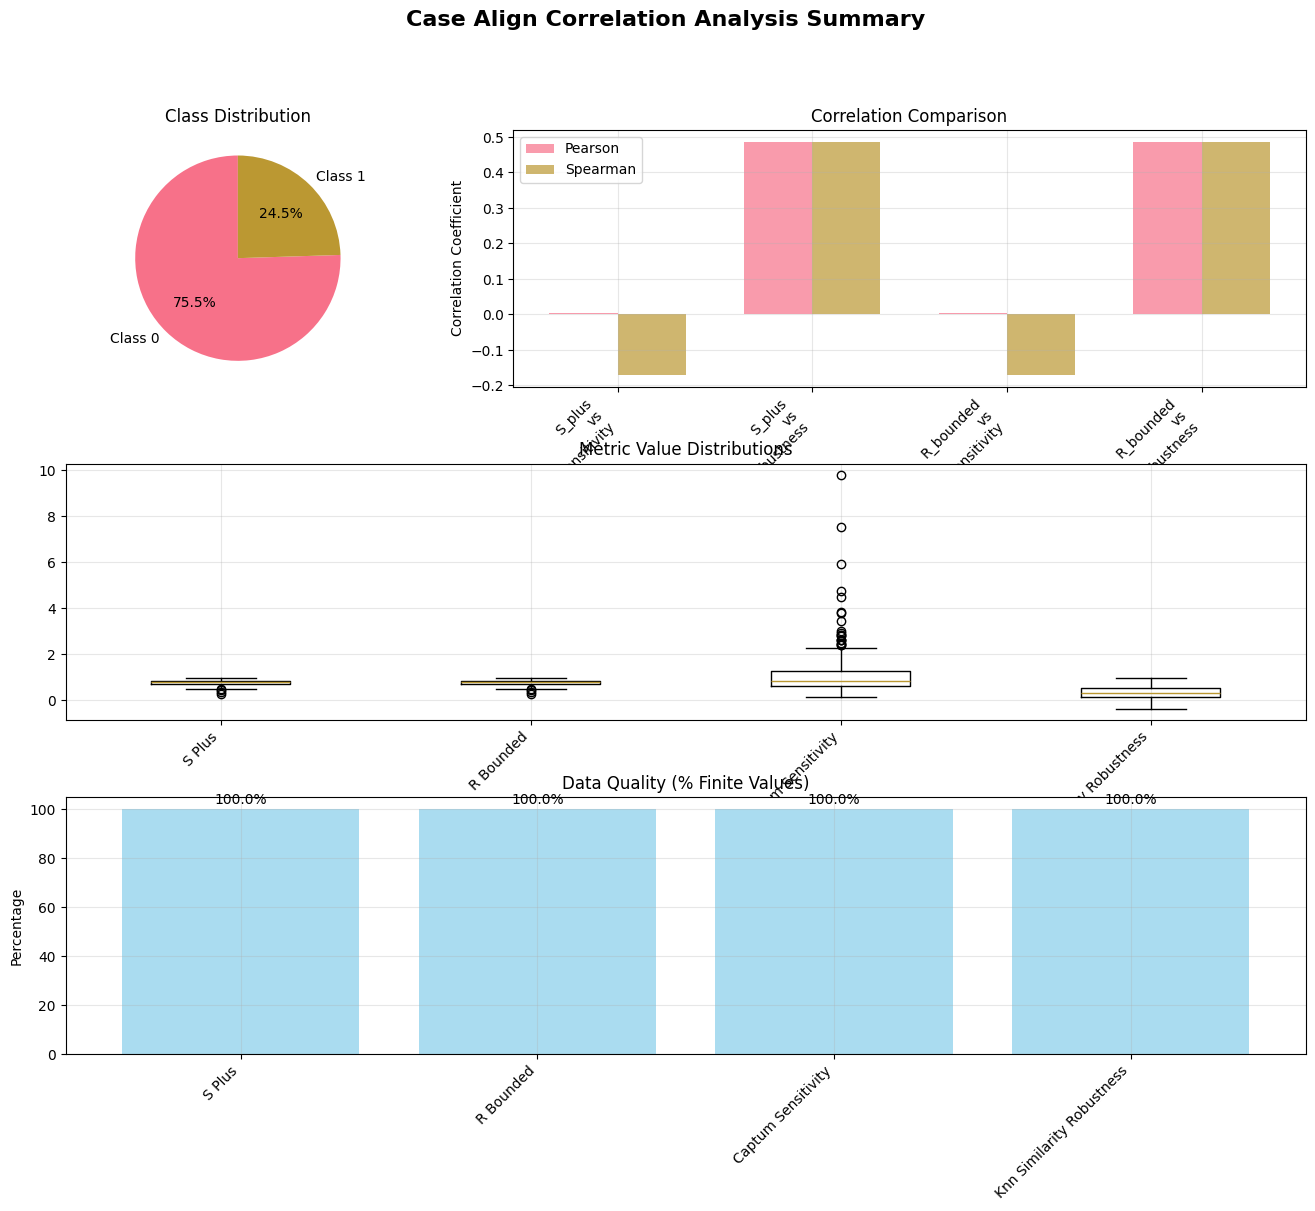

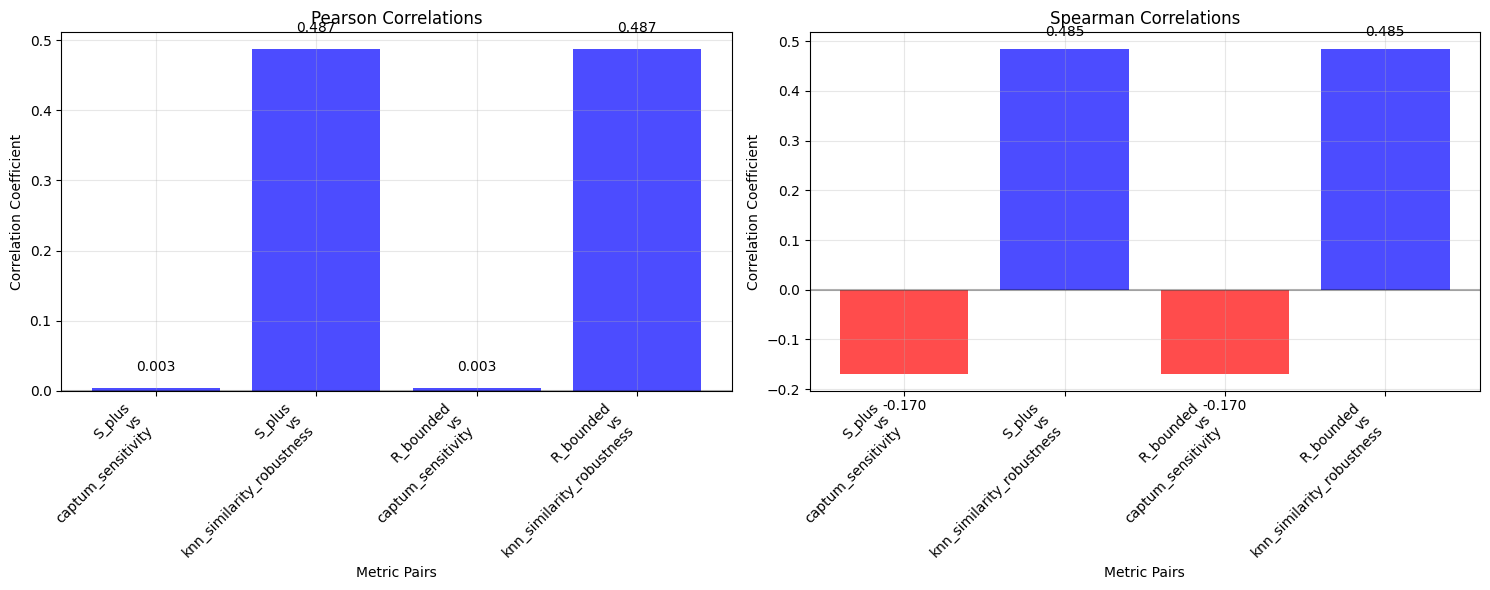

In [ ]:
# Create comprehensive analysis summary
print("Creating comprehensive analysis summary...")
create_analysis_summary_plot(df, corr_results_df)

# Plot correlation summary
plot_correlation_summary(corr_results_df)

# UMAP + HDBSCAN Visualization Experiment

This experiment uses UMAP for dimensionality reduction and HDBSCAN for clustering analysis to visualize the adult dataset. Each sample is colored by its case align (S+) score to identify patterns between robustness and data regions.

## Objectives:
1. Identify if low/high/OOD regions correspond to robustness scores
2. Understand spatial distribution of case alignment scores
3. Detect potential data quality issues or outliers

In [ ]:
# Save results if requested
if save_results:
    import pathlib
    results_dir = pathlib.Path('../results')
    results_dir.mkdir(exist_ok=True)
    
    # Save correlation results
    corr_file = results_dir / f'{DATASET}_correlation_results.csv'
    corr_results_df.to_csv(corr_file, index=False)
    print(f"✓ Saved correlation results to {corr_file}")
    
    # Save full dataset with metrics
    data_file = results_dir / f'{DATASET}_analysis_data.csv'
    df.to_csv(data_file, index=False)
    print(f"✓ Saved analysis data to {data_file}")
else:
    print("Results not saved (save_results=False)")

Results not saved (save_results=False)


In [ ]:
# Final summary statistics
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)

print(f"Dataset: {DATASET}")
print(f"Total samples analyzed: {len(df)}")
print(f"K value used: {K}")
print(f"Noise epsilon: {EPSILON}")

print(f"\nKey findings:")
if not corr_results_df.empty:
    best_corr = corr_results_df.loc[corr_results_df['pearson_r'].abs().idxmax()]
    print(f"Strongest correlation: {best_corr['case_align_metric']} vs {best_corr['traditional_metric']}")
    print(f"Pearson r = {best_corr['pearson_r']:.3f}")
    
print("\n✓ Analysis complete!")


FINAL ANALYSIS SUMMARY
Dataset: adult
Total samples analyzed: 200
K value used: 5
Noise epsilon: 0.1

Key findings:
Strongest correlation: S_plus vs knn_similarity_robustness
Pearson r = 0.487

✓ Analysis complete!
